In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor # Para comparar
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
#importacion de los datos
data=pd.read_csv('currentPriceCrypto.csv')
data.head()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,2025-06-04 20:36:49,Algorand,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,2025-06-04 20:48:25,Cosmos,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,2025-06-04 21:28:54,Cosmos,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2025-06-04 21:57:48,Ethereum,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,2025-06-04 22:06:40,Solana,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8


In [3]:
data.tail()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
2058,2025-07-04 17:16:03,Cardano,0.4492,-4.66,6345791.01,8.185563e+09,0.327,0.009,2.54,1695,56.5,77.3,51.9,72.4
2059,2025-07-04 17:25:39,Ethereum,3077.3009,0.33,590629.81,2.546980e+13,-0.277,-0.143,2.31,1093,40.1,30.4,40.5,79.2
2060,2025-07-04 17:43:50,Polkadot,8.1297,11.93,24276229.78,1.224982e+11,0.216,0.001,3.07,401,51.7,93.3,41.6,71.0
2061,2025-07-04 19:31:59,Polygon,1.1212,-7.76,2126227.67,2.240884e+10,0.144,0.160,2.32,202,66.3,76.2,37.6,74.8
2062,2025-07-04 19:58:28,Ethereum,3312.5590,3.12,9458225.78,2.011575e+13,0.005,0.622,5.02,276,53.5,71.3,42.7,72.8


In [4]:
#info de los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 2063 non-null   object 
 1   cryptocurrency            2063 non-null   object 
 2   current_price_usd         2063 non-null   float64
 3   price_change_24h_percent  2063 non-null   float64
 4   trading_volume_24h        2063 non-null   float64
 5   market_cap_usd            2063 non-null   float64
 6   social_sentiment_score    2063 non-null   float64
 7   news_sentiment_score      2063 non-null   float64
 8   news_impact_score         2063 non-null   float64
 9   social_mentions_count     2063 non-null   int64  
 10  fear_greed_index          2063 non-null   float64
 11  volatility_index          2063 non-null   float64
 12  rsi_technical_indicator   2063 non-null   float64
 13  prediction_confidence     2063 non-null   float64
dtypes: float

In [5]:
#describe de los datos
data.describe()

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
count,2063.000000,2063.000000,2.063000e+03,2.063000e+03,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000
mean,4260.360520,-0.018042,5.889564e+06,4.568510e+13,0.011158,0.002375,3.688366,1218.317014,50.494910,76.436937,50.501503,77.123413
std,12603.767442,8.000837,7.451165e+06,1.581473e+14,0.303325,0.308788,1.712072,2501.245623,13.367164,21.245765,15.116517,6.651359
min,0.298700,-25.560000,2.060664e+05,5.022090e+07,-1.000000,-1.000000,0.070000,2.000000,0.000000,21.400000,1.400000,55.900000
25%,1.208650,-5.755000,1.835157e+06,1.113379e+10,-0.197500,-0.202000,2.390000,143.500000,41.400000,60.700000,40.250000,72.650000
50%,13.344200,0.020000,3.633502e+06,1.255924e+11,0.012000,0.007000,3.670000,409.000000,50.600000,79.000000,50.500000,76.700000
75%,84.970000,5.755000,7.111602e+06,7.634962e+11,0.215000,0.211500,4.970000,1178.000000,59.400000,100.000000,60.550000,81.100000
max,51610.923200,27.080000,1.402925e+08,1.009556e+15,1.000000,1.000000,9.530000,35578.000000,100.000000,100.000000,97.100000,100.000000


In [6]:
##revisar si hay valores nulos
data.isnull().sum()

timestamp                   0
cryptocurrency              0
current_price_usd           0
price_change_24h_percent    0
trading_volume_24h          0
market_cap_usd              0
social_sentiment_score      0
news_sentiment_score        0
news_impact_score           0
social_mentions_count       0
fear_greed_index            0
volatility_index            0
rsi_technical_indicator     0
prediction_confidence       0
dtype: int64

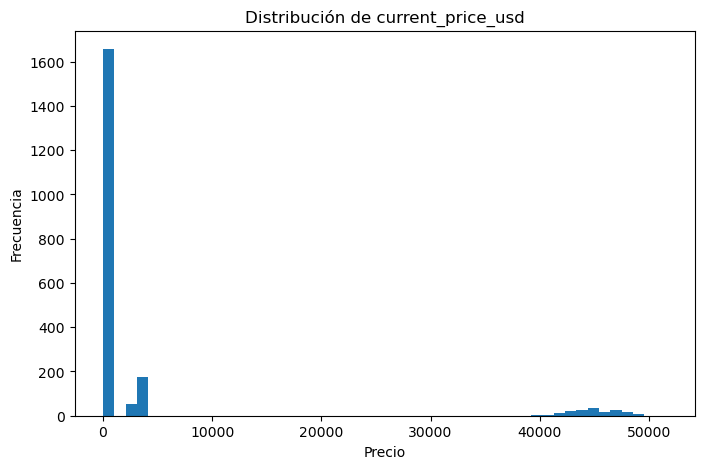

In [7]:
##grafica para ver la distribucion de precios

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data["current_price_usd"], bins=50)
plt.title("Distribución de current_price_usd")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

### se puede ver que la distribucion esta altamente sesgada a la derecha

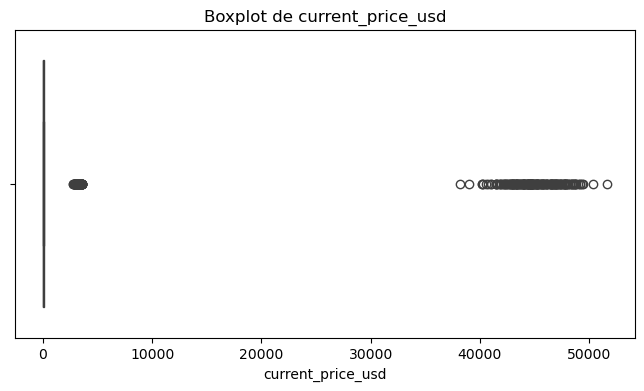

In [8]:
##grafica para ver el sesgo de los datos

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=data["current_price_usd"])
plt.title("Boxplot de current_price_usd")
plt.show()

In [9]:
##definir una nueva varaibla predictora la cual es el logaritmo de current_price_usd para un
##mejor analisis,,, esto se hace porque current_price_usd presentaba valores demasiado distantes

import numpy as np

data["log_price"] = np.log1p(data["current_price_usd"])

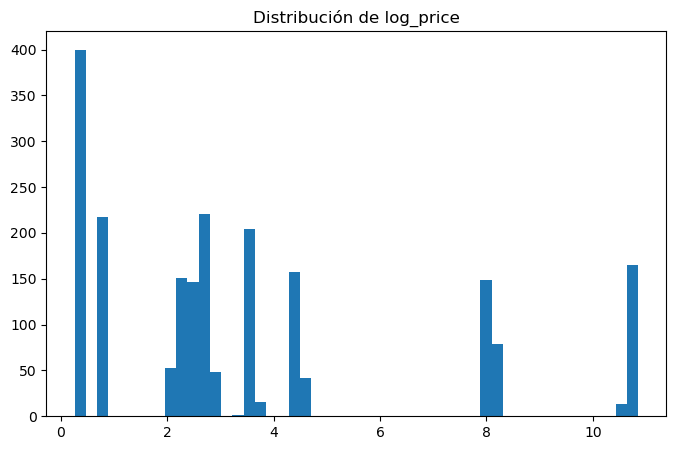

In [10]:
##grafica para ver la nueva distribucion de precios

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data["log_price"], bins=50)
plt.title("Distribución de log_price")
plt.show()

### se elimino la cola a la derecha y los valores estan mas comprimidos

In [11]:
print("Skew original:", data["current_price_usd"].skew())
print("Skew log:", data["log_price"].skew())

Skew original: 2.9327560073047914
Skew log: 1.073467645854179


### se redujo la simetria en la variable objetivo

In [12]:
#tabla que muestra la correlacion entre las varaibles predicotras
corr = data.select_dtypes(include=['number']).corr()

corr["log_price"].sort_values(ascending=False)

log_price                   1.000000
current_price_usd           0.744869
market_cap_usd              0.636826
price_change_24h_percent    0.037665
trading_volume_24h          0.036222
rsi_technical_indicator     0.028723
social_mentions_count       0.009640
volatility_index            0.005493
news_impact_score           0.005355
prediction_confidence      -0.004727
social_sentiment_score     -0.020054
news_sentiment_score       -0.029244
fear_greed_index           -0.052705
Name: log_price, dtype: float64

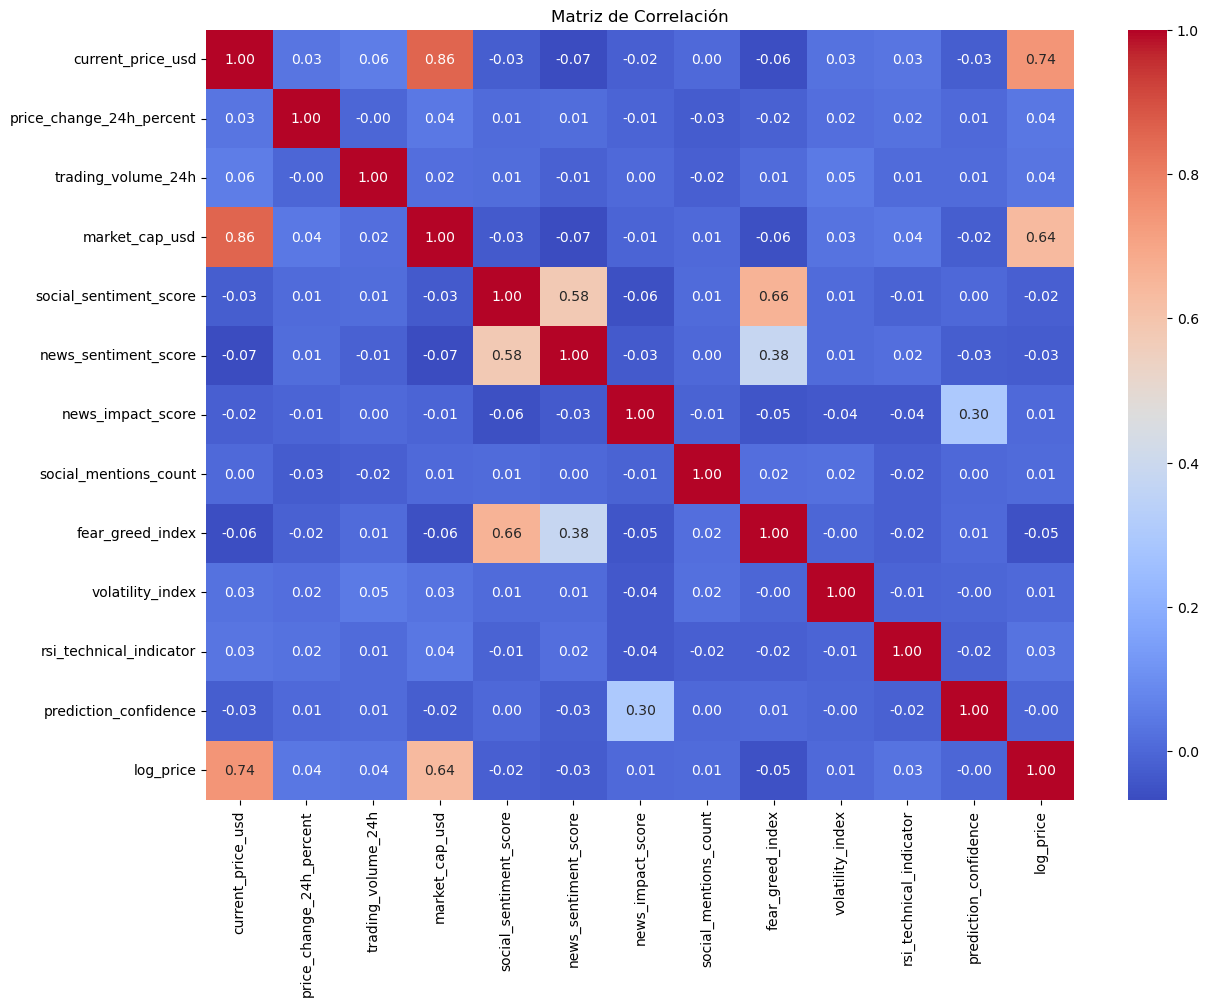

In [13]:
# Matriz de correlación de variables predictoras
corr1= data.corr(numeric_only=True)

# Gráfico
plt.figure(figsize=(14,10))
sns.heatmap(
    corr1,
    annot=True,      # muestra los valores
    cmap='coolwarm', # colores
    fmt='.2f'
)

plt.title('Matriz de Correlación')
plt.show()

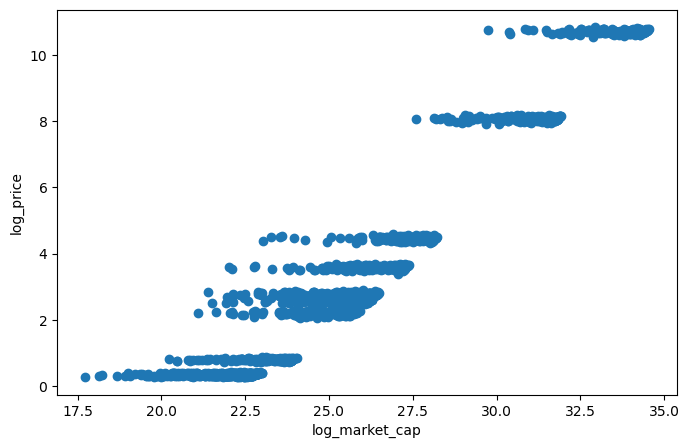

In [14]:
## diagrama de dispersion

import numpy as np

plt.figure(figsize=(8,5))
plt.scatter(
    np.log1p(data["market_cap_usd"]),
    data["log_price"]
)

plt.xlabel("log_market_cap")
plt.ylabel("log_price")
plt.show()

In [15]:
## tabla de estadisticas agrupadas

data.groupby("cryptocurrency")["current_price_usd"].agg(
    ["count","mean","median","min","max"]
).sort_values("mean")

,count,mean,median,min,max
cryptocurrency,,,,,
Algorand,202,0.351089,0.35085,0.2987,0.4068
Cardano,198,0.445756,0.44205,0.3954,0.5015
Polygon,217,1.202372,1.20370,1.0692,1.3847
Polkadot,204,7.984325,8.03155,6.8212,9.1414
Cosmos,206,11.972092,12.01240,9.9171,13.4439
Chainlink,210,14.951460,14.97710,13.1056,17.0256
Avalanche,221,34.859710,34.89640,28.8070,38.8971
Solana,199,85.156953,85.59500,74.8341,96.7097
Ethereum,228,3217.167368,3216.03835,2720.7573,3588.1675


In [16]:
## modificar al variable cryptocurrency con codificación One-Hot Encoding sobre la variable categórica cryptocurrency para 
## realizar un mejor analizis, esto genera un columna para cada tipo de criptomoneda

data_model = pd.get_dummies(
    data,
    columns=["cryptocurrency"],
    drop_first=True,
    dtype=int
)

In [17]:
data_model.head()

,timestamp,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,...,log_price,cryptocurrency_Avalanche,cryptocurrency_Bitcoin,cryptocurrency_Cardano,cryptocurrency_Chainlink,cryptocurrency_Cosmos,cryptocurrency_Ethereum,cryptocurrency_Polkadot,cryptocurrency_Polygon,cryptocurrency_Solana
0,2025-06-04 20:36:49,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,...,0.294683,0,0,0,0,0,0,0,0,0
1,2025-06-04 20:48:25,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,...,2.568175,0,0,0,0,1,0,0,0,0
2,2025-06-04 21:28:54,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,...,2.546903,0,0,0,0,1,0,0,0,0
3,2025-06-04 21:57:48,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,...,7.959375,0,0,0,0,0,1,0,0,0
4,2025-06-04 22:06:40,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,...,4.568074,0,0,0,0,0,0,0,0,1


In [18]:
## definir variable objetivo
y = data_model["log_price"]

In [19]:
## definir las variables predictoras, se eliminan variables como fecha que no se utilizan en esta caso

X = data_model.drop(
    columns=[
        "timestamp",
        "current_price_usd",
        "log_price"
    ]
)

In [20]:
##verificar la longitud de ambas variables

print(X.shape)
print(y.shape)

(2063, 20)
(2063,)


In [21]:
print(X.columns.tolist())

['price_change_24h_percent', 'trading_volume_24h', 'market_cap_usd', 'social_sentiment_score', 'news_sentiment_score', 'news_impact_score', 'social_mentions_count', 'fear_greed_index', 'volatility_index', 'rsi_technical_indicator', 'prediction_confidence', 'cryptocurrency_Avalanche', 'cryptocurrency_Bitcoin', 'cryptocurrency_Cardano', 'cryptocurrency_Chainlink', 'cryptocurrency_Cosmos', 'cryptocurrency_Ethereum', 'cryptocurrency_Polkadot', 'cryptocurrency_Polygon', 'cryptocurrency_Solana']


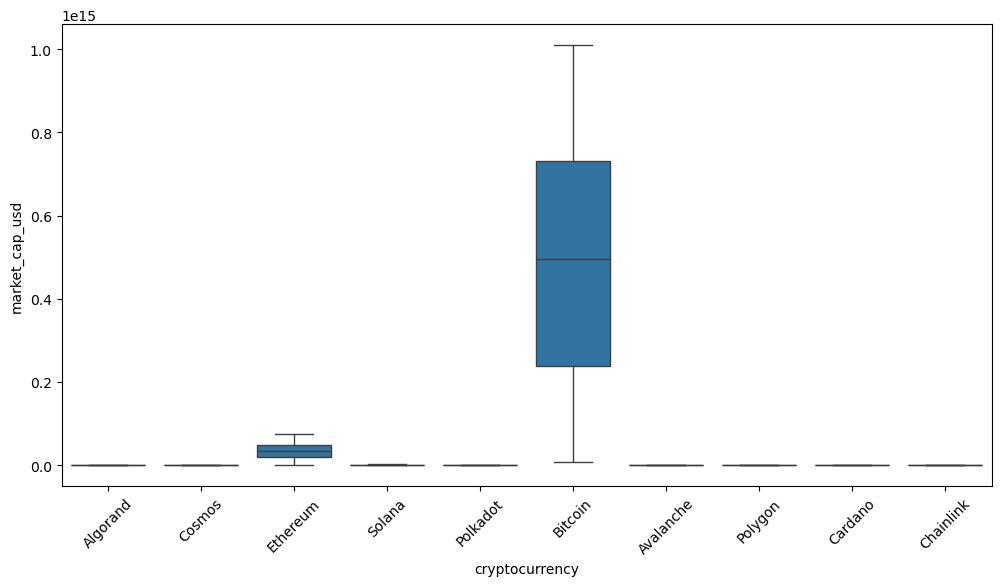

In [22]:
## distribucion de marcket cap por cirptomoneda
plt.figure(figsize=(12,6))

sns.boxplot(
    data=data,
    x="cryptocurrency",
    y="market_cap_usd"
)

plt.xticks(rotation=45)
plt.show()

In [23]:
### entrenamiento y prueba 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2026
)

In [24]:
### escalar variables 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
### entrenar regresion multiple

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
##realizar prediccion
y_pred = modelo.predict(X_test_scaled)

In [27]:
##Se calculan tres métricas MAE, RMSE Y R^2

MAE (Mean Absolute Error)
RMSE (Root Mean Squared Error)
R² (Coeficiente de Determinación)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 0.03253807569772202
RMSE = 0.04388547818244792
R² = 0.9998153315469509


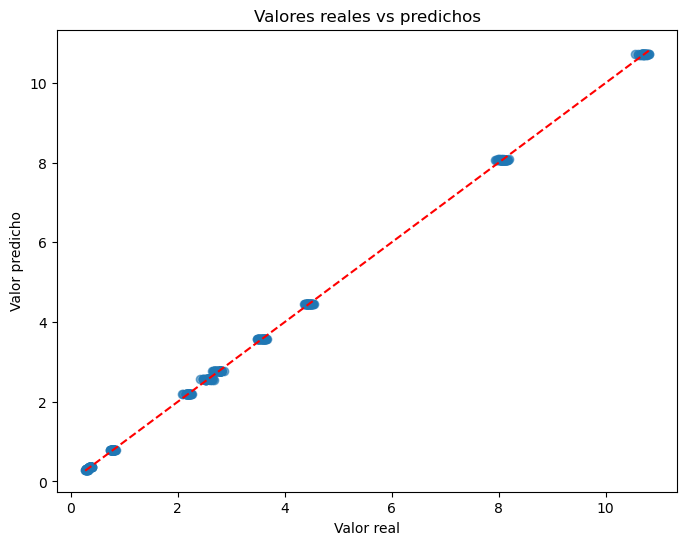

In [28]:
###Gráfico de valores reales vs. valores predichos

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Valores reales vs predichos")

plt.show()

In [29]:
## evaluar coeficientes

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

coeficientes["Abs"] = abs(coeficientes["Coeficiente"])

coeficientes.sort_values(
    "Abs",
    ascending=False
)

,Variable,Coeficiente,Abs
12,cryptocurrency_Bitcoin,2.910270,2.910270
16,cryptocurrency_Ethereum,2.417717,2.417717
19,cryptocurrency_Solana,1.239894,1.239894
11,cryptocurrency_Avalanche,1.031920,1.031920
14,cryptocurrency_Chainlink,0.741008,0.741008
15,cryptocurrency_Cosmos,0.674493,0.674493
17,cryptocurrency_Polkadot,0.575735,0.575735
18,cryptocurrency_Polygon,0.149464,0.149464
13,cryptocurrency_Cardano,0.020044,0.020044
3,social_sentiment_score,-0.001945,0.001945


La regresión múltiple indica que la variable con mayor capacidad explicativa sobre el precio de las criptomonedas es el tipo de criptomoneda (cryptocurrency), representado mediante variables dummy.

Las categorías asociadas a Bitcoin, Ethereum y Solana presentan los coeficientes más altos, evidenciando que pertenecer a estas criptomonedas incrementa significativamente el valor esperado del precio respecto a la categoría de referencia (Algorand).

Por otro lado, las variables de sentimiento social, sentimiento de noticias, volumen de negociación, RSI, volatilidad y Fear & Greed Index muestran coeficientes cercanos a cero, indicando una contribución marginal dentro del modelo.

In [30]:
### validacion cruzada 
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    modelo,
    X_train_scaled,
    y_train,
    cv=10,
    scoring="r2"
)

print(scores)
print("Promedio:", scores.mean())

[0.99980237 0.99985532 0.99985564 0.99980439 0.99982854 0.9998007
 0.99975254 0.99979005 0.99979627 0.99981588]
Promedio: 0.9998101706467539


In [31]:
nueva_obs = X_test.iloc[[0]]

pred_log = modelo.predict(
    scaler.transform(nueva_obs)
)

print(pred_log)

[2.55999333]


In [32]:
import numpy as np

pred_precio = np.expm1(pred_log)

print("Precio predicho:", pred_precio[0])

Precio predicho: 11.935730985083381


In [33]:
real = np.expm1(y_test.iloc[0])

print("Real:", real)
print("Predicho:", pred_precio[0])

Real: 12.065599999999996
Predicho: 11.935730985083381


In [34]:
nuevo = pd.DataFrame({
    'price_change_24h_percent':[2.5],
    'trading_volume_24h':[12000000],
    'market_cap_usd':[9.5e14],
    'social_sentiment_score':[0.6],
    'news_sentiment_score':[0.5],
    'news_impact_score':[4.2],
    'social_mentions_count':[15000],
    'fear_greed_index':[70],
    'volatility_index':[60],
    'rsi_technical_indicator':[55],
    'prediction_confidence':[80],

    'cryptocurrency_Avalanche':[0],
    'cryptocurrency_Bitcoin':[1],
    'cryptocurrency_Cardano':[0],
    'cryptocurrency_Chainlink':[0],
    'cryptocurrency_Cosmos':[0],
    'cryptocurrency_Ethereum':[0],
    'cryptocurrency_Polkadot':[0],
    'cryptocurrency_Polygon':[0],
    'cryptocurrency_Solana':[0]
})

In [35]:
nuevo_scaled = scaler.transform(nuevo)

pred_log = modelo.predict(nuevo_scaled)

pred_precio = np.expm1(pred_log)

print("Precio estimado:", pred_precio[0])

Precio estimado: 44919.93481744446


In [36]:
resultados = pd.DataFrame({
    "Real": np.expm1(y_test),
    "Predicho": np.expm1(y_pred)
})

resultados.head(10)

,Real,Predicho
1621,12.0656,11.935731
767,36.0357,34.595249
992,12.1771,11.947340
179,10.9044,11.957572
2059,3077.3009,3221.704650
479,44528.1343,44870.333470
1345,2986.8328,3228.947405
1189,36.4180,35.026817
56,42920.8136,44907.110408
468,0.4375,0.445188


In [37]:
import numpy as np

real = np.expm1(y_test)
pred = np.expm1(y_pred)

mape = np.mean(
    np.abs((real - pred) / real)
) * 100

print("MAPE =", mape)

MAPE = 4.187529942134112


In [38]:
### prueba con variables reducidas
X_sin_crypto = X.drop(
    columns=[
        col for col in X.columns
        if "cryptocurrency_" in col
    ]
)

print(X_sin_crypto.columns.tolist())

['price_change_24h_percent', 'trading_volume_24h', 'market_cap_usd', 'social_sentiment_score', 'news_sentiment_score', 'news_impact_score', 'social_mentions_count', 'fear_greed_index', 'volatility_index', 'rsi_technical_indicator', 'prediction_confidence']


In [39]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_sin_crypto,
    y,
    test_size=0.2,
    random_state=2026
)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

In [41]:
from sklearn.linear_model import LinearRegression

modelo2 = LinearRegression()

modelo2.fit(
    X_train2_scaled,
    y_train2
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred2 = modelo2.predict(
    X_test2_scaled
)

In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae2 = mean_absolute_error(
    y_test2,
    y_pred2
)

rmse2 = mean_squared_error(
    y_test2,
    y_pred2
) ** 0.5

r22 = r2_score(
    y_test2,
    y_pred2
)

print("MAE =", mae2)
print("RMSE =", rmse2)
print("R² =", r22)

MAE = 1.9955671078774098
RMSE = 2.544758571642978
R² = 0.37906775513174795


In [44]:
import numpy as np

real2 = np.expm1(y_test2)
pred2 = np.expm1(y_pred2)

mape2 = np.mean(
    np.abs((real2 - pred2) / real2)
) * 100

print("MAPE =", mape2)

MAPE = 1239.5499324917125


en esta prueba al eliminar el tipo de criptomoneda el rendimiento del modelo se distorciono y dejo de ser confiable

El tipo de criptomoneda es el factor más importante para la predicción del precio actual. Al eliminar las variables categóricas asociadas a la criptomoneda, el coeficiente de determinación disminuyó de 0.9998 a 0.3791 y el error porcentual medio aumentó de 4.19% a 1239.55%, evidenciando una pérdida significativa de capacidad predictiva.

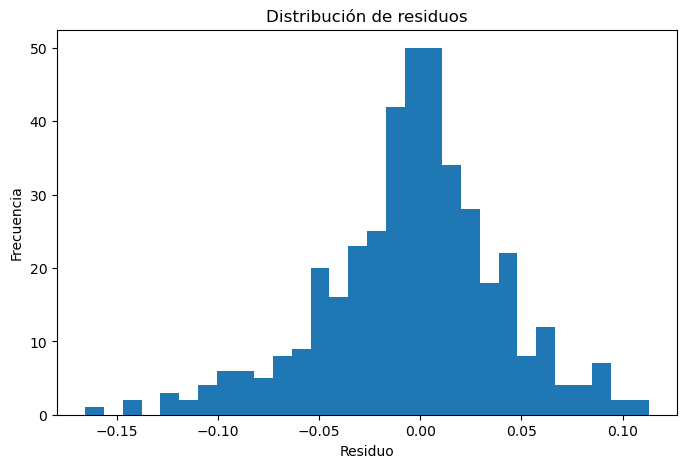

In [45]:
residuos = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuos, bins=30)
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

In [46]:
coeficientes.sort_values(
    "Abs",
    ascending=False
).head(10)

,Variable,Coeficiente,Abs
12,cryptocurrency_Bitcoin,2.910270,2.910270
16,cryptocurrency_Ethereum,2.417717,2.417717
19,cryptocurrency_Solana,1.239894,1.239894
11,cryptocurrency_Avalanche,1.031920,1.031920
14,cryptocurrency_Chainlink,0.741008,0.741008
15,cryptocurrency_Cosmos,0.674493,0.674493
17,cryptocurrency_Polkadot,0.575735,0.575735
18,cryptocurrency_Polygon,0.149464,0.149464
13,cryptocurrency_Cardano,0.020044,0.020044
3,social_sentiment_score,-0.001945,0.001945


In [47]:
residuos = y_test - y_pred

print("Media residuos:", residuos.mean())

Media residuos: -0.003901368511194673


In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values(
    by="VIF",
    ascending=False
)

print(vif)

                    Variable       VIF
2             market_cap_usd  4.027319
12    cryptocurrency_Bitcoin  3.718538
3     social_sentiment_score  2.182159
7           fear_greed_index  1.542635
4       news_sentiment_score  1.521626
11  cryptocurrency_Avalanche  1.266033
18    cryptocurrency_Polygon  1.243452
15     cryptocurrency_Cosmos  1.233699
14  cryptocurrency_Chainlink  1.233014
17   cryptocurrency_Polkadot  1.217646
13    cryptocurrency_Cardano  1.216752
19     cryptocurrency_Solana  1.209717
16   cryptocurrency_Ethereum  1.168762
5          news_impact_score  1.101130
0   price_change_24h_percent  1.007643
1         trading_volume_24h  1.005441
6      social_mentions_count  1.003599
9    rsi_technical_indicator  0.940777
8           volatility_index  0.934898
10     prediction_confidence  0.345164
